In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

RAW_DATA_ATP_PATH = os.getenv('RAW_DATA_ATP_PATH')
RAW_DATA_CHALL_PATH = os.getenv('RAW_DATA_CHALL_PATH')
DATA_2025_PATH = os.getenv('DATA_2025_PATH')
OUTPUT_PATH = os.getenv('OUTPUT_PATH')
K_FACTOR = int(os.getenv('K_FACTOR', 32))
INITIAL_ELO = int(os.getenv('INITIAL_ELO', 1500))
RAW_DATA_CHALL_PATH = os.getenv('RAW_DATA_CHALL_PATH')

# Carregar todos os dados ATP (tour, qualifiers, challengers e futures)
dfs = []
tournament_types = []  # Para rastrear o tipo de cada partida

for year in range(1992, 2025):
    # ATP Tour
    try:
        atp_tour = pd.read_csv(f'{RAW_DATA_ATP_PATH}{year}.csv')
        atp_tour['tournament_type'] = 'ATP'
        dfs.append(atp_tour)
    except FileNotFoundError:
        print(f"Arquivo atp_matches_{year}.csv não encontrado, pulando...")
    
    # ATP Qualifiers/Challengers
    try:
        chall_qual = pd.read_csv(f'{RAW_DATA_CHALL_PATH}{year}.csv')
        chall_qual['tournament_type'] = 'CHALLENGER'
        dfs.append(chall_qual)
    except FileNotFoundError:
        print(f"Arquivo atp_matches_qual_chall_{year}.csv não encontrado, pulando...")

# Adicionar dados de 2025
try:
    matches_2025 = pd.read_csv(DATA_2025_PATH)
    matches_2025['tournament_type'] = 'ATP'
    dfs.append(matches_2025)
except FileNotFoundError:
    print("Arquivo dataset_2025_normalizado.csv não encontrado, pulando...")

# Concatenar todos os DataFrames
df = pd.concat(dfs, ignore_index=True)

# Definir as superfícies
surfaces = df['surface'].unique().tolist()
print("Superfícies encontradas:", surfaces)

# Parâmetros do ELO por tipo de torneio
K_FACTORS = {
    'ATP': 32,        # K-factor original para ATP
    'CHALLENGER': 20, # K-factor reduzido para Challengers
    'ITF': 10         # K-factor mais reduzido para ITF/Futures
}

# Parâmetros para decaimento temporal
TEMPORAL_DECAY_YEARS = 5.0  # Número de anos para decaimento significativo
MIN_TEMPORAL_FACTOR = 0.3   # Fator mínimo (30% do K original para jogos muito antigos)
REFERENCE_YEAR = 2025       # Ano de referência (torneios deste ano têm fator 1.0)

#INITIAL_ELO = 1500 # ELO inicial para todos os jogadores

# Dicionário para armazenar os ELOs por superfície
elo_by_surface = {}

# Inicializar ELOs para cada superfície
for surface in surfaces:
    if pd.isna(surface):
        continue
    elo_by_surface[surface] = {}

# Função para calcular o fator de decaimento temporal
def calculate_temporal_factor(match_date):
    """
    Calcula o fator de decaimento temporal baseado na data da partida.
    Torneios mais recentes têm fator 1.0, mais antigos têm fator reduzido.
    
    Args:
        match_date (datetime): Data da partida
        
    Returns:
        float: Fator entre MIN_TEMPORAL_FACTOR e 1.0
    """
    if pd.isna(match_date):
        return 1.0
    
    # Calcular diferença em anos desde o ano de referência
    years_ago = REFERENCE_YEAR - match_date.year
    
    if years_ago <= 0:
        return 1.0  # Torneios atuais ou futuros têm fator máximo
    
    # Aplicar decaimento exponencial
    # Fórmula: MIN_FACTOR + (1 - MIN_FACTOR) * exp(-years_ago / DECAY_YEARS)
    decay_factor = np.exp(-years_ago / TEMPORAL_DECAY_YEARS)
    temporal_factor = MIN_TEMPORAL_FACTOR + (1 - MIN_TEMPORAL_FACTOR) * decay_factor
    
    return temporal_factor

# Função para calcular a probabilidade esperada
def expected_score(elo_a, elo_b):
    """
    Calcula a probabilidade esperada de vitória do jogador A contra o jogador B.
    
    Args:
        elo_a (float): ELO do jogador A
        elo_b (float): ELO do jogador B
        
    Returns:
        float: Probabilidade esperada (0 a 1)
    """
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

# Função para atualizar o ELO com K-factor variável e decaimento temporal
def update_elo(winner_elo, loser_elo, tournament_type, temporal_factor):
    """
    Atualiza os ELOs dos jogadores após uma partida.
    
    Args:
        winner_elo (float): ELO atual do vencedor
        loser_elo (float): ELO atual do perdedor
        tournament_type (str): Tipo do torneio
        temporal_factor (float): Fator de decaimento temporal
        
    Returns:
        tuple: (novo_elo_vencedor, novo_elo_perdedor)
    """
    base_K = K_FACTORS.get(tournament_type, K_FACTORS['ITF'])  # Default para CHALLENGER se não encontrar
    K = base_K * temporal_factor  # Aplicar fator temporal
    expected_win = expected_score(winner_elo, loser_elo)
    change = K * (1 - expected_win)
    winner_elo += change
    loser_elo -= change
    return winner_elo, loser_elo

# Função para limpar e padronizar nomes (opcional, mas recomendado)
def clean_name(name):
    """
    Limpa e padroniza os nomes dos jogadores.
    
    Args:
        name (str): Nome do jogador
        
    Returns:
        str: Nome limpo e padronizado
    """
    if pd.isna(name):
        return name
    # Remove espaços extras e converte para título
    return str(name).strip().title()

# Limpar os nomes dos jogadores
df['winner_name'] = df['winner_name'].apply(clean_name)
df['loser_name'] = df['loser_name'].apply(clean_name)

# Processar cada partida em ordem cronológica
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values('tourney_date')

# Inicializar dicionário para armazenar o ELO atual de cada jogador por superfície
current_elo = {surface: {} for surface in elo_by_surface.keys()}

# Listas para armazenar os ELOs durante o processamento
winner_elos = []
loser_elos = []
k_factors_used = []  # Para tracking dos K-factors utilizados
temporal_factors = []  # Para tracking dos fatores temporais
effective_k_factors = []  # Para tracking dos K-factors efetivos (base * temporal)

print(f"\nIniciando processamento de {len(df)} partidas...")

for idx, row in df.iterrows():
    if idx % 10000 == 0:
        print(f"Processadas {idx} partidas...")
        
    surface = row['surface']
    tournament_type = row['tournament_type']
    match_date = row['tourney_date']
    
    if pd.isna(surface):
        winner_elos.append(np.nan)
        loser_elos.append(np.nan)
        k_factors_used.append(np.nan)
        temporal_factors.append(np.nan)
        effective_k_factors.append(np.nan)
        continue
    
    # Usar winner_name e loser_name em vez de winner_id e loser_id
    winner_name = row['winner_name']
    loser_name = row['loser_name']
    
    # Verificar se os nomes não são nulos
    if pd.isna(winner_name) or pd.isna(loser_name):
        winner_elos.append(np.nan)
        loser_elos.append(np.nan)
        k_factors_used.append(np.nan)
        temporal_factors.append(np.nan)
        effective_k_factors.append(np.nan)
        continue
    
    # Calcular fator temporal
    temporal_factor = calculate_temporal_factor(match_date)
    
    # Obter ELO atual ou usar o inicial
    winner_elo = current_elo[surface].get(winner_name, INITIAL_ELO)
    loser_elo = current_elo[surface].get(loser_name, INITIAL_ELO)
    
    # Armazenar ELOs e fatores antes da atualização
    base_k = K_FACTORS.get(tournament_type, K_FACTORS['CHALLENGER'])
    effective_k = base_k * temporal_factor
    
    winner_elos.append(winner_elo)
    loser_elos.append(loser_elo)
    k_factors_used.append(base_k)
    temporal_factors.append(temporal_factor)
    effective_k_factors.append(effective_k)
    
    # Atualizar ELOs com K-factor específico do tipo de torneio e fator temporal
    new_winner_elo, new_loser_elo = update_elo(winner_elo, loser_elo, tournament_type, temporal_factor)
    
    # Atualizar no dicionário usando os nomes
    current_elo[surface][winner_name] = new_winner_elo
    current_elo[surface][loser_name] = new_loser_elo

# Adicionar colunas de ELO por superfície ao DataFrame
df['winner_surface_elo'] = winner_elos
df['loser_surface_elo'] = loser_elos
df['k_factor_used'] = k_factors_used
df['temporal_factor'] = temporal_factors
df['effective_k_factor'] = effective_k_factors

# Mostrar estatísticas dos K-factors utilizados
print("\nDistribuição dos K-factors base utilizados:")
print(df['k_factor_used'].value_counts().sort_index())

print("\nEstatísticas dos fatores temporais:")
print(f"Fator temporal médio: {df['temporal_factor'].mean():.3f}")
print(f"Fator temporal mínimo: {df['temporal_factor'].min():.3f}")
print(f"Fator temporal máximo: {df['temporal_factor'].max():.3f}")

print(f"\nDistribuição dos fatores temporais por faixas:")
temporal_bins = pd.cut(df['temporal_factor'], bins=[0, 0.4, 0.6, 0.8, 1.0], labels=['Muito Antigo (0-40%)', 'Antigo (40-60%)', 'Recente (60-80%)', 'Muito Recente (80-100%)'])
print(temporal_bins.value_counts())

print("\nEstatísticas dos K-factors efetivos:")
print(f"K-factor efetivo médio: {df['effective_k_factor'].mean():.2f}")
print(f"K-factor efetivo mínimo: {df['effective_k_factor'].min():.2f}")
print(f"K-factor efetivo máximo: {df['effective_k_factor'].max():.2f}")

print("\nDistribuição por tipo de torneio:")
print(df['tournament_type'].value_counts())

# Salvar os resultados
output_file = 'atp_chall_matches_2025_elo_temporal.csv'
df.to_csv(output_file, index=False)

print(f"\nProcessamento concluído! {len(df)} partidas processadas.")
print(f"Arquivo salvo como: {output_file}")

# Opcional: Mostrar alguns exemplos dos ELOs finais por superfície
print("\n=== EXEMPLOS DE ELOs FINAIS POR SUPERFÍCIE ===")
for surface in list(current_elo.keys())[:3]:  # Mostrar apenas 3 superfícies
    if current_elo[surface]:
        print(f"\nTop 5 jogadores em {surface}:")
        sorted_players = sorted(current_elo[surface].items(), key=lambda x: x[1], reverse=True)[:5]
        for player_name, elo in sorted_players:
            print(f"  {player_name}: {elo:.2f}")

# Função adicional para consultar ELO de um jogador específico por superfície
def get_player_elo(player_name, surface=None):
    """
    Consulta o ELO atual de um jogador
    
    Args:
        player_name (str): Nome do jogador
        surface (str, optional): Superfície específica. Se None, mostra todas.
    
    Returns:
        dict ou float: ELO(s) do jogador
    """
    player_name = clean_name(player_name)
    
    if surface:
        return current_elo.get(surface, {}).get(player_name, f"Jogador {player_name} não encontrado em {surface}")
    else:
        player_elos = {}
        for surf in current_elo:
            if player_name in current_elo[surf]:
                player_elos[surf] = current_elo[surf][player_name]
        return player_elos if player_elos else f"Jogador {player_name} não encontrado"

# Função para obter ranking por superfície
def get_surface_ranking(surface, top_n=10):
    """
    Obtém o ranking atual de uma superfície específica.
    
    Args:
        surface (str): Nome da superfície
        top_n (int): Número de jogadores no ranking
        
    Returns:
        list: Lista de tuplas (posição, nome, elo)
    """
    if surface not in current_elo:
        return f"Superfície {surface} não encontrada"
    
    sorted_players = sorted(current_elo[surface].items(), key=lambda x: x[1], reverse=True)
    ranking = []
    for i, (player_name, elo) in enumerate(sorted_players[:top_n], 1):
        ranking.append((i, player_name, elo))
    
    return ranking

# Exemplo de uso das funções
print("\n=== EXEMPLO DE USO DAS FUNÇÕES ===")
print("Para usar as funções, descomente as linhas abaixo e substitua pelos nomes reais:")
# print("ELO do Novak Djokovic:", get_player_elo("Novak Djokovic"))
# print("ELO do Rafael Nadal em Clay:", get_player_elo("Rafael Nadal", "Clay"))
# print("Top 5 em Hard Court:", get_surface_ranking("Hard", 5))
# print("Previsão Djokovic vs Nadal em Clay:", predict_match("Novak Djokovic", "Rafael Nadal", "Clay"))

# Análise adicional do impacto temporal
print("\n=== ANÁLISE DO IMPACTO TEMPORAL ===")
print("Exemplos de fatores temporais por ano:")
for year in [1992, 2000, 2010, 2015, 2020, 2024, 2025]:
    sample_date = pd.to_datetime(f'{year}0601', format='%Y%m%d')  # 1 de junho do ano
    factor = calculate_temporal_factor(sample_date)
    print(f"Ano {year}: Fator temporal = {factor:.3f} ({factor*100:.1f}% do K-factor original)")

print(f"\nPara um torneio ATP (K-factor base = 32):")
for year in [1992, 2000, 2010, 2020, 2025]:
    sample_date = pd.to_datetime(f'{year}0601', format='%Y%m%d')
    factor = calculate_temporal_factor(sample_date)
    effective_k = 32 * factor
    print(f"Ano {year}: K-factor efetivo = {effective_k:.1f}")
    
print(f"\nConfiguração atual:")
print(f"- Decaimento temporal: {TEMPORAL_DECAY_YEARS} anos")
print(f"- Fator mínimo: {MIN_TEMPORAL_FACTOR} ({MIN_TEMPORAL_FACTOR*100:.0f}%)")
print(f"- Ano de referência: {REFERENCE_YEAR}")
print(f"- Torneios do ano {REFERENCE_YEAR}: fator 1.0 (100%)")
print(f"- Torneios de {REFERENCE_YEAR-int(TEMPORAL_DECAY_YEARS)} anos atrás: fator ≈ {MIN_TEMPORAL_FACTOR + (1-MIN_TEMPORAL_FACTOR)*np.exp(-1):.2f}")


Superfícies encontradas: ['Hard', 'Carpet', 'Clay', 'Grass', nan]

Iniciando processamento de 305498 partidas...
Processadas 0 partidas...
Processadas 10000 partidas...
Processadas 20000 partidas...
Processadas 30000 partidas...
Processadas 40000 partidas...
Processadas 50000 partidas...
Processadas 60000 partidas...
Processadas 70000 partidas...
Processadas 80000 partidas...
Processadas 90000 partidas...
Processadas 100000 partidas...
Processadas 110000 partidas...
Processadas 120000 partidas...
Processadas 130000 partidas...
Processadas 140000 partidas...
Processadas 150000 partidas...
Processadas 160000 partidas...
Processadas 170000 partidas...
Processadas 180000 partidas...
Processadas 190000 partidas...
Processadas 200000 partidas...
Processadas 210000 partidas...
Processadas 220000 partidas...
Processadas 230000 partidas...
Processadas 240000 partidas...
Processadas 250000 partidas...
Processadas 260000 partidas...
Processadas 270000 partidas...
Processadas 280000 partidas...
Pr

Plotando ELO para: Carlos Alcaraz


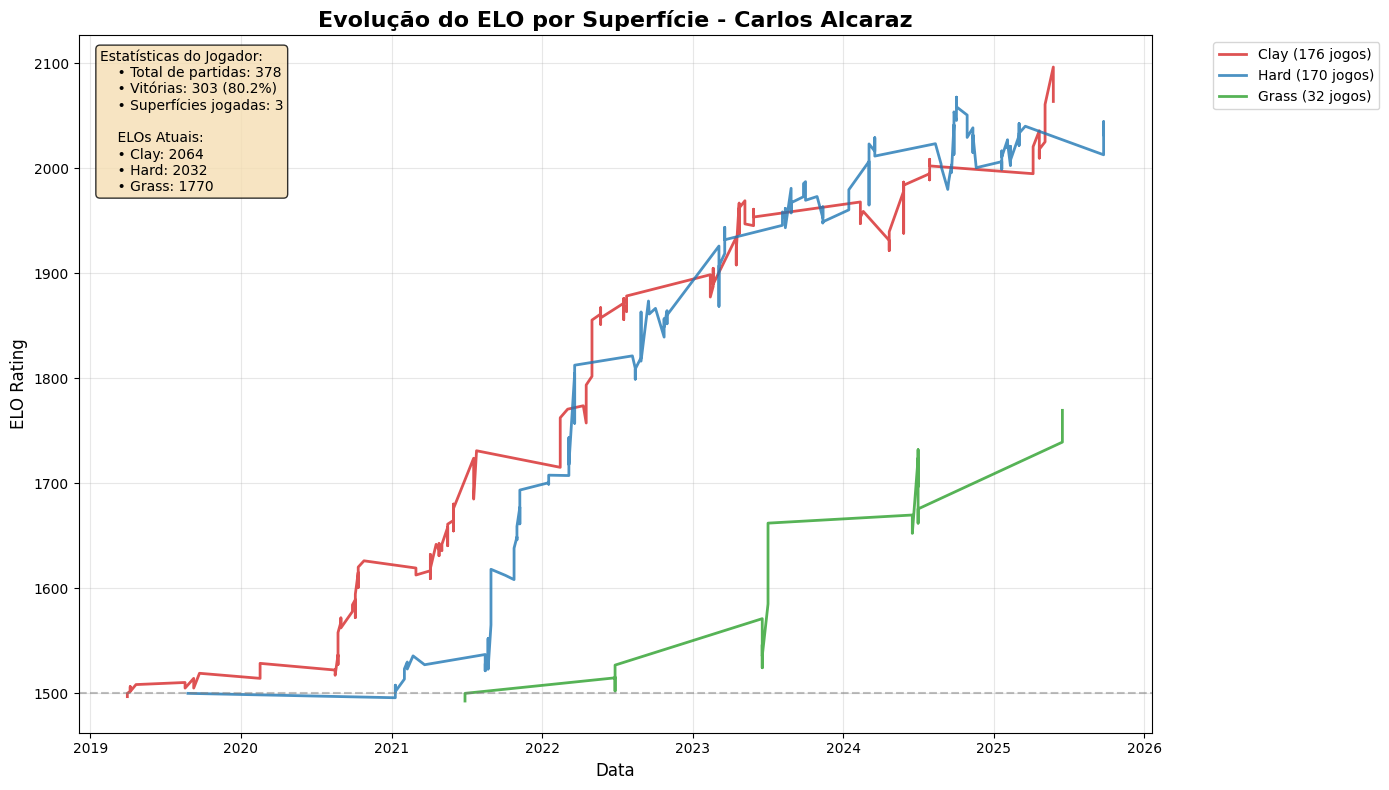


=== ESTATÍSTICAS DE CARLOS ALCARAZ ===
Nome: Carlos Alcaraz
Total de partidas: 378
Vitórias: 303 (80.2%)
Derrotas: 75
Superfícies jogadas: Clay, Hard, Grass
Período: 2019-04-01 a 2025-09-24
ELOs atuais:
  • Clay: 2064.0
  • Hard: 2032.0
  • Grass: 1770.0


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Função para obter histórico de ELO de um jogador
def get_player_history(df, player_name):
    """
    Obtém o histórico completo de ELO de um jogador em todas as superfícies.
    
    Args:
        df (DataFrame): DataFrame com os dados das partidas
        player_name (str): Nome do jogador
        
    Returns:
        DataFrame: Histórico do jogador ordenado por data
    """
    # Padronizar o nome do jogador
    player_name = player_name.strip().title()
    
    # Buscar partidas onde o jogador ganhou
    winner_matches = df[df['winner_name'] == player_name][
        ['tourney_date', 'surface', 'winner_surface_elo', 'tournament_type', 'temporal_factor']
    ].copy()
    winner_matches = winner_matches.rename(columns={'winner_surface_elo': 'surface_elo'})
    winner_matches['result'] = 'Win'
    
    # Buscar partidas onde o jogador perdeu
    loser_matches = df[df['loser_name'] == player_name][
        ['tourney_date', 'surface', 'loser_surface_elo', 'tournament_type', 'temporal_factor']
    ].copy()
    loser_matches = loser_matches.rename(columns={'loser_surface_elo': 'surface_elo'})
    loser_matches['result'] = 'Loss'
    
    # Combinar e ordenar por data
    player_history = pd.concat([winner_matches, loser_matches]).sort_values('tourney_date')
    
    return player_history

# Função para plotar ELO de um jogador
def plot_player_elo(df, player_name, figsize=(14, 8), show_results=False):
    """
    Plota o ELO de um jogador por superfície ao longo do tempo.
    
    Args:
        df (DataFrame): DataFrame com os dados das partidas
        player_name (str): Nome do jogador
        figsize (tuple): Tamanho da figura
        show_results (bool): Se True, marca vitórias e derrotas no gráfico
    """
    # Obter histórico do jogador
    player_history = get_player_history(df, player_name)
    
    if player_history.empty:
        print(f"Jogador '{player_name}' não encontrado no dataset.")
        return None
    
    # Criar o gráfico
    fig, ax = plt.subplots(figsize=figsize)
    
    # Cores para diferentes superfícies
    surface_colors = {
        'Hard': '#1f77b4',
        'Clay': '#d62728', 
        'Grass': '#2ca02c',
        'Carpet': '#ff7f0e'
    }
    
    # Plotar linha para cada superfície
    surfaces_plotted = []
    for surface in player_history['surface'].unique():
        if pd.isna(surface):
            continue
            
        surface_data = player_history[player_history['surface'] == surface]
        if surface_data.empty:
            continue
            
        color = surface_colors.get(surface, '#7f7f7f')
        
        # Linha principal do ELO
        ax.plot(surface_data['tourney_date'], surface_data['surface_elo'], 
               label=f'{surface} ({len(surface_data)} jogos)', 
               linewidth=2, color=color, alpha=0.8)
        
        # Opcionalmente, marcar vitórias e derrotas
        if show_results:
            wins = surface_data[surface_data['result'] == 'Win']
            losses = surface_data[surface_data['result'] == 'Loss']
            
            ax.scatter(wins['tourney_date'], wins['surface_elo'], 
                      color=color, marker='^', s=30, alpha=0.6, label=f'{surface} Vitórias')
            ax.scatter(losses['tourney_date'], losses['surface_elo'], 
                      color=color, marker='v', s=30, alpha=0.6, label=f'{surface} Derrotas')
        
        surfaces_plotted.append(surface)
    
    # Configurar o gráfico
    ax.set_title(f'Evolução do ELO por Superfície - {player_name}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('ELO Rating', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Adicionar linha horizontal no ELO inicial
    ax.axhline(y=1500, color='gray', linestyle='--', alpha=0.5, label='ELO Inicial (1500)')
    
    # Estatísticas do jogador
    total_matches = len(player_history)
    wins = len(player_history[player_history['result'] == 'Win'])
    win_rate = (wins / total_matches) * 100 if total_matches > 0 else 0
    
    # ELOs atuais por superfície
    current_elos = {}
    for surface in surfaces_plotted:
        surface_data = player_history[player_history['surface'] == surface]
        if not surface_data.empty:
            current_elos[surface] = surface_data.iloc[-1]['surface_elo']
    
    # Adicionar texto com estatísticas
    stats_text = f"""Estatísticas do Jogador:
    • Total de partidas: {total_matches}
    • Vitórias: {wins} ({win_rate:.1f}%)
    • Superfícies jogadas: {len(surfaces_plotted)}
    
    ELOs Atuais:"""
    
    for surface, elo in current_elos.items():
        stats_text += f"\n    • {surface}: {elo:.0f}"
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top', 
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return player_history

# Substituir pelo nome do jogador desejado
player_name = "Carlos Alcaraz"

print(f"Plotando ELO para: {player_name}")

# Plotar ELO básico (apenas linhas)
history = plot_player_elo(df, player_name)

# Se quiser ver com marcadores de vitórias/derrotas (mais detalhado)
# history = plot_player_elo(df, player_name, show_results=True)

# Função adicional para comparar múltiplos jogadores
def compare_players_elo(df, player_names, surface='Hard', figsize=(14, 8)):
    """
    Compara o ELO de múltiplos jogadores em uma superfície específica.
    
    Args:
        df (DataFrame): DataFrame com os dados das partidas
        player_names (list): Lista de nomes dos jogadores
        surface (str): Superfície para comparação
        figsize (tuple): Tamanho da figura
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, player_name in enumerate(player_names):
        player_history = get_player_history(df, player_name)
        
        if player_history.empty:
            print(f"Jogador '{player_name}' não encontrado.")
            continue
            
        surface_data = player_history[player_history['surface'] == surface]
        
        if surface_data.empty:
            print(f"Jogador '{player_name}' não tem dados para {surface}.")
            continue
        
        color = colors[i % len(colors)]
        ax.plot(surface_data['tourney_date'], surface_data['surface_elo'], 
               label=f'{player_name} ({len(surface_data)} jogos)', 
               linewidth=2, color=color, alpha=0.8)
    
    ax.set_title(f'Comparação de ELO em {surface}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('ELO Rating', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1500, color='gray', linestyle='--', alpha=0.5, label='ELO Inicial')
    
    plt.tight_layout()
    plt.show()

# Exemplo de comparação entre jogadores (descomente para usar)
# players_to_compare = ["Novak Djokovic", "Rafael Nadal", "Roger Federer"]
# compare_players_elo(df, players_to_compare, surface='Hard')

# Função para obter estatísticas rápidas de um jogador
def get_player_stats(df, player_name):
    """
    Obtém estatísticas rápidas de um jogador.
    
    Args:
        df (DataFrame): DataFrame com os dados das partidas
        player_name (str): Nome do jogador
        
    Returns:
        dict: Dicionário com estatísticas do jogador
    """
    player_history = get_player_history(df, player_name)
    
    if player_history.empty:
        return {"error": f"Jogador '{player_name}' não encontrado"}
    
    stats = {
        "player_name": player_name,
        "total_matches": len(player_history),
        "wins": len(player_history[player_history['result'] == 'Win']),
        "losses": len(player_history[player_history['result'] == 'Loss']),
        "surfaces_played": list(player_history['surface'].dropna().unique()),
        "current_elos": {},
        "date_range": {
            "first_match": player_history['tourney_date'].min(),
            "last_match": player_history['tourney_date'].max()
        }
    }
    
    stats["win_rate"] = (stats["wins"] / stats["total_matches"]) * 100
    
    # ELOs atuais por superfície
    for surface in stats["surfaces_played"]:
        surface_data = player_history[player_history['surface'] == surface]
        if not surface_data.empty:
            stats["current_elos"][surface] = round(surface_data.iloc[-1]['surface_elo'], 0)
    
    return stats

# Exemplo de uso das estatísticas
print(f"\n=== ESTATÍSTICAS DE {player_name.upper()} ===")
player_stats = get_player_stats(df, player_name)

if "error" not in player_stats:
    print(f"Nome: {player_stats['player_name']}")
    print(f"Total de partidas: {player_stats['total_matches']}")
    print(f"Vitórias: {player_stats['wins']} ({player_stats['win_rate']:.1f}%)")
    print(f"Derrotas: {player_stats['losses']}")
    print(f"Superfícies jogadas: {', '.join(player_stats['surfaces_played'])}")
    print(f"Período: {player_stats['date_range']['first_match'].strftime('%Y-%m-%d')} a {player_stats['date_range']['last_match'].strftime('%Y-%m-%d')}")
    print(f"ELOs atuais:")
    for surface, elo in player_stats['current_elos'].items():
        print(f"  • {surface}: {elo}")
else:
    print(player_stats["error"])